# 04_backtest_grid.py 결과 확인 (가치주 점수 방식)

`data/backtest_results_score_all`에 저장된 백테스트 결과를 확인한다.
2026-07-31 ValuePick `Top100Service.scoreAll()`과 동일한 7팩터 백분위 가중합산 점수 방식으로
04번을 전환한 뒤 첫 전체 실행(21,870개 전략: 리밸런싱2 x portfolio_size5 x 가중치프리셋2,187) 결과다.
기존 PER/PBR/배당 문턱값 그리드 버전은 `check_04_backtest_threshold.ipynb`로 보존돼 있다.

- 전략별 최종 성과(누적수익률/MDD/샤프비율) 상위·하위 랭킹
- monthly vs quarterly 리밸런싱 주기별 비교
- 특정 전략 하나의 구간별 수익률 시계열 확인
- 종목 보유 수(held_count) 추이로 F-Score 필터 통과 종목 수가 시점별로 어떻게 변하는지 확인
- portfolio_size(n3~n100)별 누적수익률 비교
- 가중치프리셋(7팩터 가중치)별 성과 비교 - 어떤 가중치 조합이 이 표본에서 상위인지

**주의**: 아래에서 확인하는 "최고 성과 가중치프리셋"은 2021~2023년 KOSPI+KOSDAQ 표본 안에서
사후적으로 가장 높은 성과를 낸 조합일 뿐이다. 그리드 탐색으로 이 표본 최고 성과 조합은 확정할 수
있지만, 그 조합이 표본 밖(다른 기간·다른 시장)에서도 최적이라는 뜻은 아니다 (오버피팅 위험 -
2026-07-31 사용자와 확인된 원칙). "이상적/최적 가중치"라 부르지 않고 "이 표본 최고 성과 조합"으로
서술한다.

In [1]:
# Jupyter 컨테이너(jupyter/pyspark-notebook 이미지)에는 한글 폰트가 없어 그래프의 한글이
# 네모(tofu)로 깨진다. 컨테이너를 재생성(docker compose down/up)하면 매번 사라지므로 매 세션
# 첫 실행 시 여기서 설치한다. 이미 설치돼 있으면 스킵한다 - apt-get은 root 권한이 필요한데
# Jupyter 커널이 비root(jovyan)로 뜨는 경우 apt-get update 자체가 실패하므로(2026-08-01 실측
# 확인), 폰트가 이미 있으면 apt-get을 아예 호출하지 않는다.
import subprocess
import matplotlib.font_manager as fm

def _has_nanum() -> bool:
    fm.fontManager = fm._load_fontmanager(try_read_cache=False)
    return any("Nanum" in f.name for f in fm.fontManager.ttflist)

if not _has_nanum():
    subprocess.run(
        "apt-get update -qq && apt-get install -y -qq fonts-nanum && fc-cache -fv",
        shell=True, check=True, capture_output=True,
    )

import matplotlib.pyplot as plt

# matplotlib은 시작 시점에 폰트 목록을 캐시해두므로, 방금 설치한 폰트는 fontManager.ttflist에
# 아직 안 잡힌다(실측: 재실행해도 빈 리스트). _load_fontmanager(try_read_cache=False)로 캐시를
# 무시하고 시스템 폰트를 다시 스캔해야 나눔 폰트가 인식된다.
fm.fontManager = fm._load_fontmanager(try_read_cache=False)

nanum_fonts = [f.name for f in fm.fontManager.ttflist if "Nanum" in f.name]
if not nanum_fonts:
    raise RuntimeError("나눔 폰트 설치/인식 실패 - fc-list와 fontManager.ttflist를 직접 확인할 것")
plt.rcParams["font.family"] = nanum_fonts[0]
plt.rcParams["axes.unicode_minus"] = False  # 나눔 폰트는 유니코드 마이너스(-) 글리프가 없어 깨짐 - ASCII(-)로 대체
print(f"사용 폰트: {plt.rcParams['font.family']}")

사용 폰트: ['NanumGothic']


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import yaml

spark = SparkSession.builder.master("spark://spark-master:7077").appName("check_backtest_score").getOrCreate()

# 2026-07-31: 21,870개 전략 첫 성공 실행 결과 (shuffle.partitions=64 override로 재시도해 성공,
# 1차 시도는 shuffle.partitions=4로 돌려 메모리 스필 폭증 후 kill - PROGRESS.md 참고).
RESULT_DIR = "/opt/spark-apps/data/backtest_results_score_all"

summary = spark.read.parquet(f"{RESULT_DIR}/summary")
period = spark.read.parquet(f"{RESULT_DIR}/period_returns")

print(f"전략 수(summary): {summary.count()}")
print(f"구간 수익률 행 수(period_returns): {period.count()}")
summary.printSchema()

전략 수(summary): 21870
구간 수익률 행 수(period_returns): 503010
root
 |-- name: string (nullable = true)
 |-- final_cum_return: double (nullable = true)
 |-- mdd: double (nullable = true)
 |-- avg_period_return: double (nullable = true)
 |-- stddev_period_return: double (nullable = true)
 |-- sharpe_ratio: double (nullable = true)



In [3]:
# strategies.yaml에서 name -> 7개 가중치 매핑을 읽어온다. summary/period에는 가중치 컬럼이 없고
# name(예: w0159_monthly_n3)만 있으므로, 가중치프리셋별 분석을 하려면 이 매핑을 조인해야 한다.
# pandas로 처리하는 이유: spark.createDataFrame(strategies_raw)로 워커에 보내 조인하면
# 드라이버(Jupyter, Python 3.11)와 워커(Python 3.8)의 파이썬 마이너 버전이 달라
# PYSPARK_PYTHON 불일치 오류(PYTHON_VERSION_MISMATCH)가 실제로 재발함(2026-08-01 Jupyter 웹 UI에서
# 실측 확인 - spark-submit으로 워커와 같은 이미지 안에서 돌리면 문제없이 성공하는 것도 확인함,
# 즉 Jupyter 컨테이너와 워커 컨테이너의 파이썬 버전 자체가 다른 게 근본 원인). 워커 이미지에
# Python 3.11을 맞추는 근본 해결은 별도 이슈로 남겨두고(PROGRESS.md 참고), 여기서는 21,870행
# 규모에 충분한 로컬 pandas merge로 우회한다.
import pandas as pd

with open("/opt/spark-apps/conf/strategies.yaml", "r", encoding="utf-8") as f:
    strategies_raw = yaml.safe_load(f)["strategies"]

weight_cols = ["weight_per", "weight_pbr", "weight_roe", "weight_roa",
               "weight_debt_ratio", "weight_eps_growth", "weight_momentum"]
strategies_pd = pd.DataFrame(strategies_raw)[["name", "rebalance", "portfolio_size", *weight_cols]]

# name에서 가중치프리셋 라벨(w0000 등)만 뽑아둔다 - 같은 프리셋이 rebalance x portfolio_size
# 5x2=10개 전략에 걸쳐 반복되므로, 프리셋 단위 집계 시 이 라벨로 묶는다.
strategies_pd["weight_label"] = strategies_pd["name"].str.extract(r"^(w\d+)_")
print(f"strategies 로드: {len(strategies_pd)}개, 가중치프리셋 유일값: {strategies_pd['weight_label'].nunique()}개")

strategies 로드: 21870개, 가중치프리셋 유일값: 2187개


## 1. 누적수익률 상위 20개 전략

In [4]:
top20 = summary.filter(F.col("final_cum_return").isNotNull()) \
    .orderBy(F.desc("final_cum_return")).limit(20).toPandas()
top20

,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio
0,w2002_monthly_n3,0.858027,-0.445936,0.026158,0.139665,0.187290
1,w0159_monthly_n3,0.819197,-0.298432,0.024777,0.129187,0.191791
2,w0601_monthly_n3,0.817112,-0.446513,0.024369,0.127521,0.191100
3,w0957_monthly_n3,0.781136,-0.300046,0.025075,0.137235,0.182719
4,w0123_monthly_n3,0.751865,-0.319413,0.024331,0.135432,0.179652
5,w0969_monthly_n3,0.718000,-0.321850,0.023639,0.133621,0.176907
6,w2037_monthly_n3,0.714589,-0.340914,0.021182,0.115820,0.182884
7,w0174_monthly_n3,0.711735,-0.303862,0.023907,0.137731,0.173576
8,w1953_monthly_n3,0.706912,-0.417891,0.021791,0.123232,0.176833
9,w0888_monthly_n3,0.697411,-0.321850,0.023007,0.131060,0.175544


## 2. 누적수익률 하위 20개 전략

In [5]:
bottom20 = summary.filter(F.col("final_cum_return").isNotNull()) \
    .orderBy(F.asc("final_cum_return")).limit(20).toPandas()
bottom20

,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio
0,w0236_quarterly_n3,-0.641424,-0.666744,-0.078501,0.151887,-0.516841
1,w0212_quarterly_n3,-0.641424,-0.666744,-0.078501,0.151887,-0.516841
2,w0239_quarterly_n3,-0.641424,-0.666744,-0.078501,0.151887,-0.516841
3,w0965_quarterly_n3,-0.634466,-0.660277,-0.077544,0.147686,-0.525059
4,w0968_quarterly_n3,-0.634466,-0.660277,-0.077544,0.147686,-0.525059
5,w0884_quarterly_n3,-0.624039,-0.674961,-0.073008,0.163173,-0.447429
6,w0956_quarterly_n3,-0.621932,-0.660277,-0.074190,0.151881,-0.488474
7,w0929_quarterly_n3,-0.617646,-0.656427,-0.073447,0.150794,-0.487072
8,w0242_quarterly_n3,-0.615949,-0.643068,-0.073193,0.149050,-0.491066
9,w0215_quarterly_n3,-0.615132,-0.642308,-0.072931,0.149530,-0.487735


## 3. 샤프비율 상위 20개 전략 (수익률 대비 위험조정 성과)

In [6]:
top_sharpe = summary.filter(F.col("sharpe_ratio").isNotNull()) \
    .orderBy(F.desc("sharpe_ratio")).limit(20).toPandas()
top_sharpe

,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio
0,w1269_quarterly_n3,0.536018,-0.330773,0.054600,0.197438,0.276544
1,w1944_quarterly_n3,0.512301,-0.318239,0.053328,0.198552,0.268582
2,w1323_quarterly_n3,0.492101,-0.389536,0.051841,0.196552,0.263752
3,w1332_quarterly_n3,0.450073,-0.387465,0.047606,0.180748,0.263381
4,w0567_quarterly_n3,0.482368,-0.327213,0.050772,0.194931,0.260462
5,w0513_quarterly_n3,0.462601,-0.368090,0.050580,0.200392,0.252403
6,w1242_quarterly_n3,0.462601,-0.368090,0.050580,0.200392,0.252403
7,w1971_quarterly_n3,0.462601,-0.368090,0.050580,0.200392,0.252403
8,w0594_quarterly_n3,0.394828,-0.389536,0.042686,0.172125,0.247994
9,w2052_quarterly_n3,0.383161,-0.389536,0.041588,0.169324,0.245611


## 4. monthly vs quarterly 리밸런싱 주기 비교
전략 이름에서 rebalance 종류를 뽑아 그룹별 평균 성과를 비교한다.
(이름 규칙: `w{가중치프리셋인덱스}_{rebalance}_n{portfolio_size}`)

In [7]:
with_rebalance = summary.withColumn(
    "rebalance",
    F.when(F.col("name").contains("_monthly_"), "monthly").otherwise("quarterly"),
)

with_rebalance.groupBy("rebalance").agg(
    F.avg("final_cum_return").alias("avg_final_cum_return"),
    F.avg("mdd").alias("avg_mdd"),
    F.avg("sharpe_ratio").alias("avg_sharpe_ratio"),
    F.count("*").alias("strategy_count"),
).toPandas()

,rebalance,avg_final_cum_return,avg_mdd,avg_sharpe_ratio,strategy_count
0,monthly,-0.040689,-0.384845,0.017065,10935
1,quarterly,-0.154394,-0.392744,-0.071667,10935


## 5. 특정 전략 하나의 구간별 수익률 시계열
이름을 바꿔서 원하는 전략의 리밸런싱 구간별 수익률 흐름을 확인할 수 있다.
기본값은 섹션 1의 최고 성과 전략으로 둔다(실행마다 top20 결과가 같다면 동일한 name 유지).

In [8]:
target_strategy = top20.iloc[0]["name"]
print(f"대상 전략: {target_strategy}")

one_strategy = period.filter(F.col("name") == target_strategy) \
    .orderBy("period_start").toPandas()
one_strategy

대상 전략: w2002_monthly_n3


,name,period_start,period_end,period_return,held_count
0,w2002_monthly_n3,20210131,20210228,-0.012711,3
1,w2002_monthly_n3,20210228,20210331,0.059980,3
2,w2002_monthly_n3,20210331,20210430,0.094422,3
3,w2002_monthly_n3,20210430,20210531,0.124834,3
4,w2002_monthly_n3,20210531,20210630,-0.020145,3
5,w2002_monthly_n3,20210630,20210731,-0.054547,3
6,w2002_monthly_n3,20210731,20210831,-0.057096,3
7,w2002_monthly_n3,20210831,20210930,-0.036488,3
8,w2002_monthly_n3,20210930,20211031,0.031545,3
9,w2002_monthly_n3,20211031,20211130,-0.112969,3


### 누적수익률 곡선 그래프

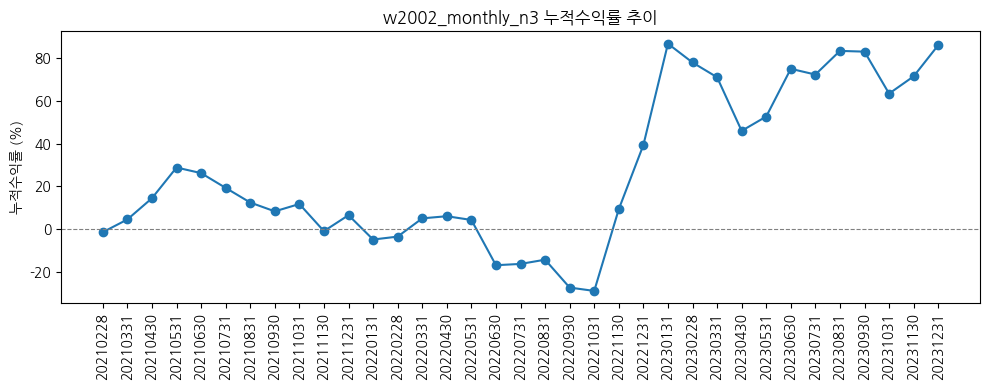

In [9]:
one_strategy["cum_return"] = (1 + one_strategy["period_return"]).cumprod() - 1

plt.figure(figsize=(10, 4))
plt.plot(one_strategy["period_end"], one_strategy["cum_return"] * 100, marker="o")
plt.xticks(rotation=90)
plt.title(f"{target_strategy} 누적수익률 추이")
plt.ylabel("누적수익률 (%)")  # cum_return은 0.5=원금의 50% 증가를 뜻하는 비율값이라 *100으로 % 표시
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")  # 원금(0%) 기준선 - 이 선 위/아래로 손익 방향이 갈린다
plt.tight_layout()
plt.show()

## 6. 종목 보유 수(held_count) 추이
시점이 갈수록 그 시점 이전에 공시된 사업보고서가 누적되므로, 초반 시점(2021년 초)은 F-Score 계산에
필요한 전년도 재무제표가 부족해 후보 자체가 적고, 뒤로 갈수록 늘어나는 것이 정상이다
(룩어헤드 바이어스 방지 로직이 실제로 작동하는 증거).

In [10]:
held_trend = period.filter(F.col("name") == target_strategy) \
    .select("period_start", "held_count").orderBy("period_start").toPandas()
held_trend

,period_start,held_count
0,20210131,3
1,20210228,3
2,20210331,3
3,20210430,3
4,20210531,3
5,20210630,3
6,20210731,3
7,20210831,3
8,20210930,3
9,20211031,3


## 7. 이상치 확인: final_cum_return이 null인 전략
구간 수익률 계산 자체가 안 된 전략(예: 어느 시점에도 F-Score 필터를 통과하는 종목이 없었던 전략)이 있는지 확인.

In [11]:
null_result = summary.filter(F.col("final_cum_return").isNull())
print(f"결과 없는 전략 수: {null_result.count()}")
null_result.toPandas()

결과 없는 전략 수: 0


,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio


## 8. portfolio_size(n3~n100)별 누적수익률 비교

`conf/generate_strategies.py`의 `PORTFOLIO_SIZE` 후보(3/10/30/50/100)마다, 같은 가중치프리셋의
나머지 전략들을 평균내 대표 누적수익률 곡선을 하나씩 그린다. "보유 종목 수가 성과에 미치는 영향"을
눈으로 확인하는 목적이다.

`period`(구간별 수익률)를 직접 쓰는 이유: `summary.final_cum_return`은 전략별 값 하나뿐이라
시계열 그래프를 그릴 수 없다. `period_return`을 시간순 복리 누적(`summarize_performance`의
`cum_return` 계산과 동일한 방식)해야 곡선이 나온다.

In [12]:
# name 끝의 _n{숫자}에서 portfolio_size를 뽑는다. conf/generate_strategies.py의 strategy_name()이
# f"..._n{portfolio_size}" 형식으로 짓는 규칙과 정확히 일치해야 한다.
with_size = period.withColumn(
    "portfolio_size", F.regexp_extract(F.col("name"), r"_n(\d+)$", 1).cast("int")
)

print(f"portfolio_size 후보: {sorted([r[0] for r in with_size.select('portfolio_size').distinct().collect()])}")

portfolio_size 후보: [3, 10, 30, 50, 100]


**monthly만 따로 본다.** portfolio_size 그룹 안에는 monthly(구간 35개)와 quarterly(구간 11개)
전략이 섞여 있는데, 리밸런싱 주기가 다르면 구간 하나의 길이(1개월치 vs 3개월치 수익률)가 달라
평균을 그대로 합치면 왜곡된다. 위 4번 섹션에서 이미 monthly/quarterly 성과 자체가 다르다는 걸
확인했으므로, 이 그래프는 리밸런싱 주기를 monthly로 고정해 portfolio_size 하나만 변수로 남긴다.

In [13]:
monthly_with_size = with_size.filter(F.col("name").contains("_monthly_"))

monthly_size_avg = monthly_with_size.groupBy("portfolio_size", "period_start", "period_end").agg(
    F.avg("period_return").alias("avg_period_return")
).orderBy("portfolio_size", "period_start").toPandas()

# 시간순 복리 누적 - summarize_performance()의 cum_return 계산(F.exp(F.sum(F.log(r+1))) - 1)과
# 같은 방식을 pandas로 재현한다. portfolio_size별로 따로 누적해야 하므로 groupby 후 cumprod.
monthly_size_avg["cum_return"] = (
    monthly_size_avg.groupby("portfolio_size")["avg_period_return"]
    .transform(lambda s: (1 + s).cumprod() - 1)
)
monthly_size_avg.head()

,portfolio_size,period_start,period_end,avg_period_return,cum_return
0,3,20210131,20210228,-0.007674,-0.007674
1,3,20210228,20210331,0.056210,0.048104
2,3,20210331,20210430,0.086779,0.139057
3,3,20210430,20210531,0.075069,0.224565
4,3,20210531,20210630,0.056844,0.294174


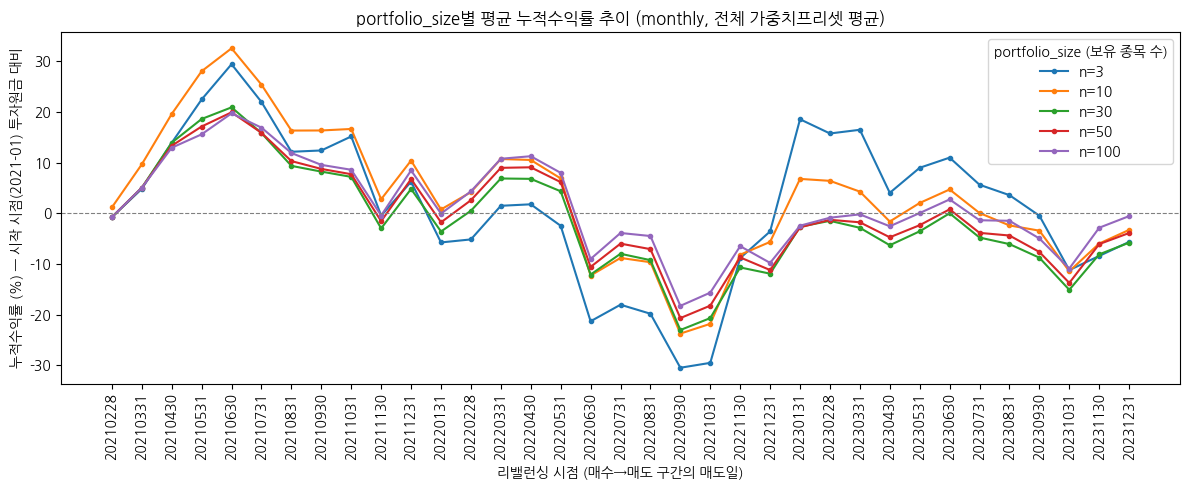

In [14]:
plt.figure(figsize=(12, 5))
for size in sorted(monthly_size_avg["portfolio_size"].unique()):
    subset = monthly_size_avg[monthly_size_avg["portfolio_size"] == size]
    plt.plot(subset["period_end"], subset["cum_return"] * 100, marker="o", markersize=3, label=f"n={size}")

plt.xticks(rotation=90)
plt.legend(title="portfolio_size (보유 종목 수)")
plt.title("portfolio_size별 평균 누적수익률 추이 (monthly, 전체 가중치프리셋 평균)")
# cum_return은 "원금 대비 몇 배 불었나"를 나타내는 비율(0.6 = +60%)이라 *100으로 %를 명시해야 읽힌다.
plt.ylabel("누적수익률 (%) — 시작 시점(2021-01) 투자원금 대비")
plt.xlabel("리밸런싱 시점 (매수→매도 구간의 매도일)")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")  # 원금(0%) 기준선
plt.tight_layout()
plt.show()

In [15]:
# 그래프의 마지막 지점(최종 누적수익률)만 뽑아 %로도 비교한다.
final_by_size = (
    monthly_size_avg.sort_values("period_end")
    .groupby("portfolio_size")
    .tail(1)[["portfolio_size", "period_end", "cum_return"]]
    .sort_values("portfolio_size")
    .reset_index(drop=True)
)
final_by_size["누적수익률(%)"] = (final_by_size["cum_return"] * 100).round(1)
final_by_size

,portfolio_size,period_end,cum_return,누적수익률(%)
0,3,20231231,-0.056597,-5.7
1,10,20231231,-0.032886,-3.3
2,30,20231231,-0.058105,-5.8
3,50,20231231,-0.039013,-3.9
4,100,20231231,-0.005682,-0.6


## 9. 가중치프리셋별 성과 비교

이전(문턱값 그리드) 노트북의 섹션 9("PER/PBR/배당 조건별 n비교")에 대응하는 부분이다. 점수 방식은
조건이 아니라 **7팩터 가중치 조합**이 그리드 축이므로, 여기서는 가중치프리셋(w0000~w2186)별로
성과를 비교하고 실제 가중치 값(PER/PBR/ROE/ROA/부채비율/EPS성장률/모멘텀)까지 함께 확인한다.

**다시 강조**: 아래에서 나오는 "상위 가중치프리셋"은 2021~2023년 표본 안에서의 사후 최고 성과일
뿐, 일반화된 최적 가중치가 아니다.

In [16]:
# summary(전략 단위, name = w{idx}_{rebalance}_n{size})를 pandas로 뽑아 strategies_pd와
# 로컬에서 merge한다 (Spark join 대신 - 위 셀 설명 참고, 워커 파이썬 버전 불일치 회피).
summary_pd = summary.select("name", "final_cum_return", "sharpe_ratio").toPandas()
summary_with_weights = summary_pd.merge(strategies_pd, on="name", how="inner")

# 같은 가중치프리셋(weight_label)이 rebalance x portfolio_size 10개 전략에 걸쳐 반복되므로,
# 프리셋 단위로 평균내 "이 가중치 조합 자체가 대체로 잘 되는지"를 본다(개별 전략 하나의 우연이 아니라).
preset_avg = summary_with_weights.groupby(["weight_label"] + weight_cols).agg(
    avg_final_cum_return=("final_cum_return", "mean"),
    avg_sharpe_ratio=("sharpe_ratio", "mean"),
    strategy_count=("name", "count"),
).reset_index()

print(f"가중치프리셋 수: {len(preset_avg)}개 (프리셋당 전략 수 확인: strategy_count는 전부 10이어야 함)")
top_presets = preset_avg.sort_values("avg_final_cum_return", ascending=False).head(20).reset_index(drop=True)
top_presets

가중치프리셋 수: 2187개 (프리셋당 전략 수 확인: strategy_count는 전부 10이어야 함)


,weight_label,weight_per,weight_pbr,weight_roe,weight_roa,weight_debt_ratio,weight_eps_growth,weight_momentum,avg_final_cum_return,avg_sharpe_ratio,strategy_count
0,w1944,44.871795,32.051282,12.820513,0.000000,6.410256,3.846154,0.000000,0.119812,0.080506,10
1,w1945,39.772727,28.409091,11.363636,0.000000,5.681818,3.409091,11.363636,0.115885,0.078509,10
2,w0486,25.862069,43.103448,17.241379,0.000000,8.620690,5.172414,0.000000,0.108013,0.079835,10
3,w1215,36.764706,36.764706,14.705882,0.000000,7.352941,4.411765,0.000000,0.106360,0.077219,10
4,w1947,43.750000,31.250000,12.500000,0.000000,6.250000,6.250000,0.000000,0.079998,0.063670,10
5,w1227,31.250000,31.250000,12.500000,0.000000,18.750000,6.250000,0.000000,0.079259,0.042545,10
6,w1953,39.772727,28.409091,11.363636,0.000000,17.045455,3.409091,0.000000,0.076653,0.042317,10
7,w1950,42.682927,30.487805,12.195122,0.000000,6.097561,8.536585,0.000000,0.076577,0.066136,10
8,w0492,24.193548,40.322581,16.129032,0.000000,8.064516,11.290323,0.000000,0.076008,0.062928,10
9,w1224,32.051282,32.051282,12.820513,0.000000,19.230769,3.846154,0.000000,0.075169,0.044960,10


### 9-1. 상위 프리셋의 가중치 구성을 원본(ValuePick 기본값)과 비교
원본 가중치: PER25/PBR15/ROE20/ROA10/부채비율15/EPS성장률5/모멘텀10.
상위 프리셋들이 원본 대비 어느 팩터를 강조/약화했는지 한눈에 본다.

In [17]:
baseline = {"weight_per": 25, "weight_pbr": 15, "weight_roe": 20, "weight_roa": 10,
            "weight_debt_ratio": 15, "weight_eps_growth": 5, "weight_momentum": 10}

diff_df = top_presets[["weight_label", "avg_final_cum_return"] + weight_cols].copy()
for col in weight_cols:
    diff_df[f"{col}_diff"] = (diff_df[col] - baseline[col]).round(1)
diff_df[["weight_label", "avg_final_cum_return"] + [f"{c}_diff" for c in weight_cols]]

,weight_label,avg_final_cum_return,weight_per_diff,weight_pbr_diff,weight_roe_diff,weight_roa_diff,weight_debt_ratio_diff,weight_eps_growth_diff,weight_momentum_diff
0,w1944,0.119812,19.9,17.1,-7.2,-10.0,-8.6,-1.2,-10.0
1,w1945,0.115885,14.8,13.4,-8.6,-10.0,-9.3,-1.6,1.4
2,w0486,0.108013,0.9,28.1,-2.8,-10.0,-6.4,0.2,-10.0
3,w1215,0.106360,11.8,21.8,-5.3,-10.0,-7.6,-0.6,-10.0
4,w1947,0.079998,18.8,16.2,-7.5,-10.0,-8.8,1.2,-10.0
5,w1227,0.079259,6.2,16.2,-7.5,-10.0,3.8,1.2,-10.0
6,w1953,0.076653,14.8,13.4,-8.6,-10.0,2.0,-1.6,-10.0
7,w1950,0.076577,17.7,15.5,-7.8,-10.0,-8.9,3.5,-10.0
8,w0492,0.076008,-0.8,25.3,-3.9,-10.0,-6.9,6.3,-10.0
9,w1224,0.075169,7.1,17.1,-7.2,-10.0,4.2,-1.2,-10.0


### 9-2. 하위 20개 프리셋 (참고용 - 어떤 조합이 이 표본에서 특히 부진했는지)

In [18]:
bottom_presets = preset_avg.sort_values("avg_final_cum_return", ascending=True).head(20).reset_index(drop=True)
bottom_presets

,weight_label,weight_per,weight_pbr,weight_roe,weight_roa,weight_debt_ratio,weight_eps_growth,weight_momentum,avg_final_cum_return,avg_sharpe_ratio,strategy_count
0,w0512,14.705882,24.509804,9.803922,0.000000,24.509804,6.862745,19.607843,-0.210058,-0.085664,10
1,w0266,16.666667,16.666667,11.111111,0.000000,27.777778,5.555556,22.222222,-0.209509,-0.085332,10
2,w0269,16.304348,16.304348,10.869565,0.000000,27.173913,7.608696,21.739130,-0.199214,-0.078123,10
3,w0503,16.304348,27.173913,10.869565,0.000000,16.304348,7.608696,21.739130,-0.188333,-0.068872,10
4,w0189,22.058824,7.352941,44.117647,14.705882,7.352941,4.411765,0.000000,-0.186046,-0.075575,10
5,w0746,30.487805,6.097561,12.195122,0.000000,18.292683,8.536585,24.390244,-0.184852,-0.074273,10
6,w0500,16.666667,27.777778,11.111111,0.000000,16.666667,5.555556,22.222222,-0.183346,-0.067451,10
7,w0175,18.750000,6.250000,37.500000,0.000000,18.750000,6.250000,12.500000,-0.182671,-0.074389,10
8,w0263,17.045455,17.045455,11.363636,0.000000,28.409091,3.409091,22.727273,-0.181545,-0.070640,10
9,w0357,20.833333,20.833333,27.777778,13.888889,6.944444,9.722222,0.000000,-0.179963,-0.084198,10


### 9-3. 팩터별 가중치와 평균 성과의 상관관계
"이 팩터 가중치를 올릴수록 성과가 좋아지는 경향이 있는가"를 팩터별로 대략 본다. 21,870개 전략을
가중치프리셋(2,187개) 단위로 평균내 correlation을 계산 - 개별 팩터 하나의 영향력만 보려는 것이지
인과관계를 증명하는 것은 아니다(다른 팩터와의 상호작용은 반영되지 않음).

In [19]:
preset_avg_pd = preset_avg[weight_cols + ["avg_final_cum_return"]]
corr = preset_avg_pd.corr()["avg_final_cum_return"].drop("avg_final_cum_return").sort_values(ascending=False)
corr.to_frame("팩터가중치 vs 평균누적수익률 상관계수")

,팩터가중치 vs 평균누적수익률 상관계수
weight_pbr,0.505110
weight_per,0.155250
weight_eps_growth,0.002674
weight_debt_ratio,-0.012363
weight_roa,-0.135682
weight_roe,-0.146255
weight_momentum,-0.361747


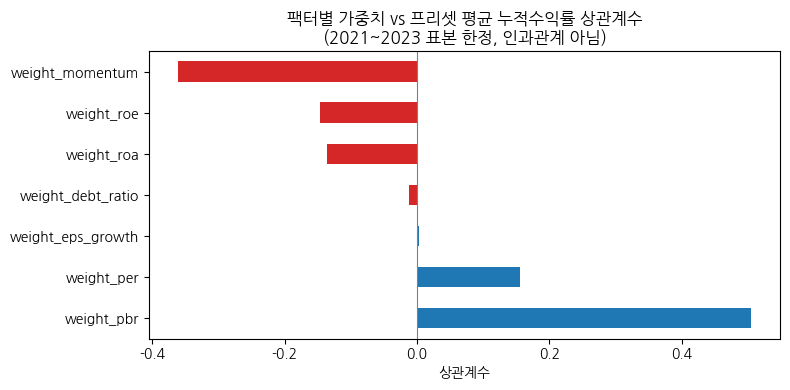

In [20]:
plt.figure(figsize=(8, 4))
corr.plot(kind="barh", color=["tab:red" if v < 0 else "tab:blue" for v in corr.values])
plt.title("팩터별 가중치 vs 프리셋 평균 누적수익률 상관계수\n(2021~2023 표본 한정, 인과관계 아님)")
plt.xlabel("상관계수")
plt.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

In [21]:
spark.stop()

## 10. 결과 해석 (2026-08-01 정리)

이 노트북(ValuePick `Top100Service.scoreAll()` 재현, 7팩터 백분위 가중합산 점수, 21,870개 전략,
2021~2023 KOSPI+KOSDAQ 전체)의 실행 결과에서 확인된 사실과 추론.

### 알아낸 사실

1. **monthly가 quarterly보다 전체 평균으로 확실히 우수했다** (섹션 4).
   monthly 평균 -4.07% vs quarterly 평균 -15.44% (전략 10,935개씩 평균). 샤프비율도 monthly는
   평균 0.017(양수)인데 quarterly는 평균 -0.072(음수)다. 문턱값 그리드 노트북(섹션 4)에서도
   같은 방향(monthly > quarterly)이 확인됐으므로, 이건 스크리닝 방식(문턱값 vs 점수)과
   무관하게 **이 3년 표본 자체의 성격**(하락장에서는 자주 재편입하는 쪽이 유리)일 가능성이 높다.

2. **portfolio_size는 작을수록(n3) 극단값이 커졌다 - 상/하위 20개가 거의 다 n3** (섹션 1, 2).
   최고 성과 `w2002_monthly_n3`(+85.8%)부터 최저 `w0236/w0212/w0239_quarterly_n3`(-64.1%,
   3개 동률)까지 전부 n3다. `held_count`(섹션 6)를 보면 이 전략은 매 시점 정확히 3종목만
   보유했다 — 소수 종목 몰빵이라 어느 한 종목의 등락이 전체 성과를 좌우한다. 실제로
   `w2002_monthly_n3`의 구간 수익률(섹션 5)을 보면 2022-10~2023-01 세 구간에서 각각
   +53.3%, +27.3%, +33.9%로 튀는 구간이 있다 — 소수 종목의 급등이 그대로 전체 수익률에
   반영된 사례로 보인다.
   반면 monthly 전체 가중치프리셋 평균(섹션 8)으로 보면 portfolio_size별 최종 성과가
   n3 -5.7%, n10 -3.3%, n30 -5.8%, n50 -3.9%, n100 -0.6%로 문턱값 그리드 때처럼 뚜렷한
   단조 개선은 아니었다 — 점수 방식은 F-Score 필터로 후보군 자체가 이미 좁혀져 있어서
   (2023년 기준 2,368종목 중 1,127종목만 후보), 문턱값 그리드와 다른 양상을 보이는 것으로
   추정된다.

3. **PBR 가중치가 가장 강한 양의 상관, 모멘텀 가중치가 가장 강한 음의 상관** (섹션 9-3).
   ```
   weight_pbr          0.505   (가장 강한 양의 상관)
   weight_per          0.155
   weight_eps_growth   0.003
   weight_debt_ratio  -0.012
   weight_roa         -0.136
   weight_roe         -0.146
   weight_momentum    -0.362   (가장 강한 음의 상관)
   ```
   PBR 가중치를 올릴수록, 모멘텀 가중치를 낮출수록 이 표본에서 프리셋 평균 성과가 좋아지는
   경향이 뚜렷했다. 실제 상위 프리셋(섹션 9, 9-1)을 보면 1위 `w1944`가 원본(PER25/PBR15) 대비
   PER +19.9%p, PBR +17.1%p로 둘 다 올리고 모멘텀은 -10%p(즉 0%로 하한)로 낮춘 조합이다.
   상위 20개 프리셋 거의 전부가 `weight_momentum_diff = -10.0`(모멘텀 가중치를 후보 최저값인
   0으로 낮춤)이었다.
   해석: 모멘텀(추세 추종)은 상승장에서 유리한 팩터인데, 2021~2023년은 전반적 하락/횡보
   구간이 많았으니 "추세를 따라가는" 전략이 손해를 봤을 가능성이 있다. 반대로 PBR을 강하게
   미는(더 저평가된 종목을 고르는) 전략이 하락장에서 상대적으로 방어적이었을 수 있다.

4. **F-Score 필터는 과도하게 걸러내지도, 무의미하게 다 통과시키지도 않았다** (별도 검증,
   PROGRESS.md 참고). 2023년 기준 전체 2,368종목 중 1,127종목(약 48%)이 F-Score≥6 또는
   금융업 예외로 통과했다 — 필터가 실제로 작동하고 있다는 근거.

5. **F-Score 필터 통과 후보가 없어 계산 자체가 실패한 전략은 0건** (섹션 7). 21,870개 전략
   전부 `final_cum_return`이 계산됐다.

### 문턱값 그리드(threshold)와 비교했을 때 눈에 띄는 차이

- 문턱값 그리드는 배당수익률 조건(`dy`)이 있는 전략이 압도적으로 유리했다(threshold 노트북 섹션
  1, 2, 9-1). 점수 방식은 애초에 배당수익률을 점수 팩터로 쓰지 않으므로(Java 원본
  `scoreAll()`이 배당수익률을 포함하지 않음) 이 비교 자체를 할 수 없다 — 두 방식이 아예 다른
  팩터 집합을 쓴다는 점을 다시 확인한 셈이다.
- 문턱값 그리드는 portfolio_size가 클수록(n300) 뚜렷하게 개선됐지만, 점수 방식은 그 정도로
  뚜렷한 단조 패턴이 안 보였다(위 2번). F-Score 사전 필터가 후보군을 절반 정도로 좁혀놓은
  상태에서 상위 점수만 뽑다 보니, 단순 문턱값 필터보다 "이미 어느 정도 선별된 풀" 안에서
  n을 늘리는 효과가 상대적으로 작았을 가능성이 있다(가설, 추가 검증 필요).

### 이 표본에서만 유효한 해석 (일반화 경고 — 앞서 사용자와 확인한 원칙)

- 위 "상위 가중치프리셋"과 상관계수는 **2021~2023년 KOSPI+KOSDAQ 3년 표본**에서 나온 사후
  관찰이다. 이 조합이 표본 밖(다른 기간, 다른 시장)에서도 최선이라는 근거는 없다 — "이상적
  가중치"가 아니라 "이 표본 최고 성과 조합"으로만 읽어야 한다.
- "모멘텀 가중치가 낮을수록 좋다"는 결과는 이 3년이 하락/횡보장이었다는 조건에 강하게
  의존한다. 상승장이 포함된 다른 기간에서는 부호가 반대로 나올 가능성이 있다.